In [75]:
# !unzip pedestrians.zip -d train
# !unzip "Test images-pedestrians.zip" -d test/
import scipy
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# HOG

In [76]:
from typing import Tuple

class HOG():
    def __init__(self):
        pass

    def get_max_from_channels(self, mag: np.ndarray, angle: np.ndarray):
        if mag.ndim == 2:
            return mag

        if mag.shape[2] != 3:
            raise ValueError(f"Expected 3 channels, got shape {mag.shape}")

        output_mag = np.zeros(mag.shape[:2])
        output_angle = np.zeros(mag.shape[:2])

        max_0 = np.logical_and(
            mag[:, :, 1] < mag[:, :, 0],
            mag[:, :, 2] < mag[:, :, 0],
        )
        output_mag[max_0] = mag[:, :, 0][max_0]
        output_angle[max_0] = angle[:, :, 0][max_0]

        max_1 = np.logical_and(
            mag[:, :, 0] < mag[:, :, 1],
            mag[:, :, 2] < mag[:, :, 1],
        )
        output_mag[max_1] = mag[:, :, 1][max_1]
        output_angle[max_1] = angle[:, :, 1][max_1]

        max_2 = np.logical_and(
            mag[:, :, 0] < mag[:, :, 2],
            mag[:, :, 1] < mag[:, :, 2],
        )
        output_mag[max_2] = mag[:, :, 2][max_2]
        output_angle[max_2] = angle[:, :, 2][max_2]

        return output_mag, output_angle

    def get_max_grad_mag_angle(self, Img: np.ndarray):
        dx = scipy.ndimage.convolve1d(np.int32(Img), np.array([-1, 0, 1]), axis=1).astype(float)
        dy = scipy.ndimage.convolve1d(np.int32(Img), np.array([-1, 0, 1]), axis=0).astype(float)

        magnitude = np.sqrt(dx ** 2 + dy ** 2)
        angle = np.degrees(np.arctan2(dy, dx)) % 180  # in degrees and wrapped into [0, 180)

        max_magnitude, max_angle = self.get_max_from_channels(magnitude, angle)

        return max_magnitude, max_angle

    def get_block_histogram(self, Imgs: tuple, cellSize=8):
        magnitude, angle = Imgs
        h, w = magnitude.shape
        n_cells_x = h // cellSize
        n_cells_y = w // cellSize

        n_bins = 9
        bin_size = 180 // n_bins
        hist = np.zeros((n_cells_x, n_cells_y, n_bins))

        for i in range(n_cells_x):
            for j in range(n_cells_y):
                mag_cell = magnitude[i * cellSize:(i + 1) * cellSize, j * cellSize:(j + 1) * cellSize]
                ang_cell = angle[i * cellSize:(i + 1) * cellSize, j * cellSize:(j + 1) * cellSize]

                for x in range(cellSize):
                    for y in range(cellSize):
                        mag = mag_cell[x, y]
                        ang = ang_cell[x, y]

                        bin_idx = int(ang // bin_size) % n_bins
                        next_bin = (bin_idx + 1) % n_bins
                        ratio = (ang % bin_size) / bin_size

                        hist[i, j, bin_idx] += mag * (1 - ratio)
                        hist[i, j, next_bin] += mag * ratio

        return hist

    def normalize_blocks(self, hist, eps=1e-5):
        X_cells, Y_cells, n_bins = hist.shape
        blocks = []
        for i in range(X_cells - 1):
            for j in range(Y_cells - 1):
                block = np.concatenate((
                    hist[i, j],
                    hist[i, j + 1],
                    hist[i + 1, j],
                    hist[i + 1, j + 1]
                ))
                norm = np.linalg.norm(block) + eps
                blocks.append(block / norm)
        return np.concatenate(blocks)
    
    def HOGpicture(self, w, bs):
        """
        Visualize HOG histogram bins as an image.
        :param w: HOG histograms of shape (cells_x, cells_y, 9)
        :param bs: cell size (e.g., 8)
        :return: an image with the visualization
        """
        # Create a base line pattern
        bim1 = np.zeros((bs, bs))
        bim1[int(np.round(bs // 2)) : int(np.round(bs // 2)) + 1, :] = 1

        # Create rotated patterns for each of 9 orientations
        bim = np.zeros(bim1.shape + (9,))
        for i in range(9):
            angle = -i * 20  # 9 bins from 0 to 160 degrees (exclusive)
            rotated = scipy.ndimage.rotate(bim1, angle, reshape=False, order=0)
            bim[:, :, i] = rotated / 255.0

        # Clip negative histogram values
        w = np.clip(w, 0, None)
        Y, X, Z = w.shape
        im = np.zeros((bs * Y, bs * X))

        for i in range(Y):
            iisl = i * bs
            iisu = (i + 1) * bs
            for j in range(X):
                jjsl = j * bs
                jjsu = (j + 1) * bs
                for k in range(9):
                    im[iisl:iisu, jjsl:jjsu] += bim[:, :, k] * w[i, j, k]

        return im


Wektor cech HOG: [0.32978975 0.26618968 0.0894292  0.12710123 0.13599635 0.10239203
 0.08956411 0.15279103 0.14236293 0.31997485]
Długość wektora: 3780


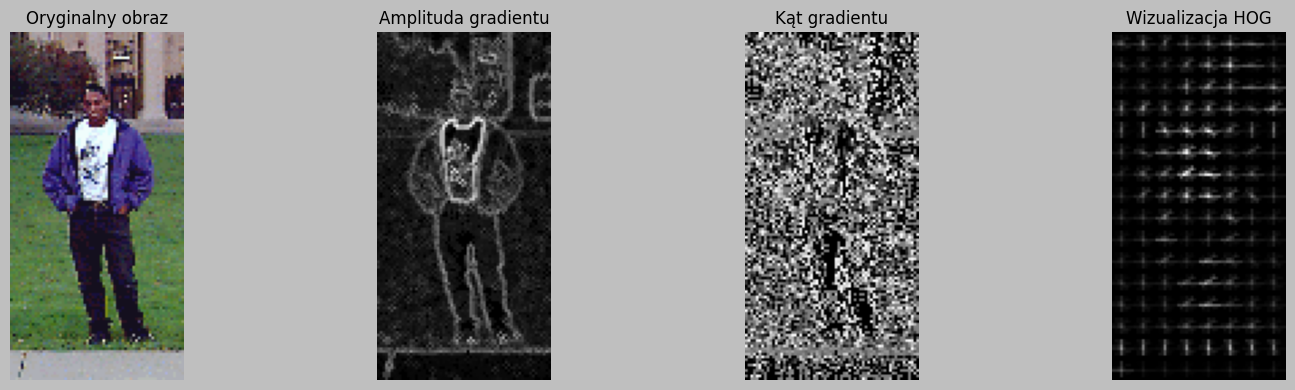

In [77]:
example_human = cv2.imread("train/pos/per00060.ppm")
hog = HOG()
mag, ang = hog.get_max_grad_mag_angle(example_human)
hist = hog.get_block_histogram((mag, ang), cellSize=8)
descriptor = hog.normalize_blocks(hist)

print("Wektor cech HOG:", descriptor[:10])  # pierwsze 10 wartości
print("Długość wektora:", len(descriptor))  # powinno być ~3780 dla 64x128


plt.style.use('grayscale')
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(example_human, cv2.COLOR_BGR2RGB))
axes[0].set_title("Oryginalny obraz")
axes[1].imshow(mag, cmap='gray')
axes[1].set_title("Amplituda gradientu")
axes[2].imshow(ang, cmap='gray')
axes[2].set_title("Kąt gradientu")
axes[3].imshow(hog.HOGpicture(hist, 8), cmap='gray')
axes[3].set_title("Wizualizacja HOG")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# SVM

In [78]:
class HOG_SVM_Classifier:
    def __init__(self, hog_obj, pos_path='train/pos', neg_path='train/neg', 
                 pos_prefix='per', neg_prefix='neg', pos_ext='.ppm', neg_ext='.png',
                 n_samples=200, cell_size=8):
        self.hog = hog_obj
        self.pos_path = pos_path
        self.neg_path = neg_path
        self.pos_prefix = pos_prefix
        self.neg_prefix = neg_prefix
        self.pos_ext = pos_ext
        self.neg_ext = neg_ext
        self.n_samples = n_samples
        self.cell_size = cell_size
        self.clf = svm.SVC(kernel='linear', C=1.0)
        self.HOG_data = None
        self.labels = None
        self.data = None

    def compute_descriptor(self, image):
        # Zakładamy, że obraz ma rozmiar 64x128 lub go skalujemy
        if image.shape[0] != 128 or image.shape[1] != 64:
            image = cv2.resize(image, (64,128))
        # Używamy Twojej klasy HOG:
        magnitude, angle = self.hog.get_max_grad_mag_angle(image)
        hist = self.hog.get_block_histogram((magnitude, angle))
        descriptor = self.hog.normalize_blocks(hist)
        return descriptor

    def extract_hog_features(self):
        print("Extracting HOG features...")
        HOG_data = np.zeros([2 * self.n_samples, 3781], dtype=np.float32)  # 3780 + 1 label
        for i in range(self.n_samples):
            # Pozytywne
            pos_file = f'{self.pos_path}/{self.pos_prefix}{i+1:05d}{self.pos_ext}'
            IP = cv2.imread(pos_file)
            mag, ang = self.hog.get_max_grad_mag_angle(IP)
            hist = self.hog.get_block_histogram((mag, ang), cellSize=self.cell_size)
            desc = self.hog.normalize_blocks(hist)
            HOG_data[i, 0] = 1
            HOG_data[i, 1:] = desc

            # Negatywne
            neg_file = f'{self.neg_path}/{self.neg_prefix}{i+1:05d}{self.neg_ext}'
            IN = cv2.imread(neg_file)
            mag, ang = self.hog.get_max_grad_mag_angle(IN)
            hist = self.hog.get_block_histogram((mag, ang), cellSize=self.cell_size)
            desc = self.hog.normalize_blocks(hist)
            HOG_data[i + self.n_samples, 0] = 0
            HOG_data[i + self.n_samples, 1:] = desc

        self.HOG_data = HOG_data
        self.labels = HOG_data[:, 0]
        self.data = HOG_data[:, 1:]

    def train(self):
        if self.data is None or self.labels is None:
            raise ValueError("No data. Run extract_hog_features() first.")
        print("Training SVM classifier...")
        self.clf.fit(self.data, self.labels)

    def evaluate(self):
        print("Evaluating on training data...")
        preds = self.clf.predict(self.data)
        cm = confusion_matrix(self.labels, preds)
        TP = cm[1, 1]
        TN = cm[0, 0]
        FP = cm[0, 1]
        FN = cm[1, 0]
        accuracy = (TP + TN) / np.sum(cm)
        print("Confusion Matrix:\n", cm)
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        print(f"Training accuracy: {accuracy * 100:.2f}%")
        return cm, accuracy

    def validate(self, test_size=0.2, random_state=42):
        print(f"Splitting data with test size = {test_size}")
        X_train, X_test, y_train, y_test = train_test_split(
            self.data, self.labels, test_size=test_size, random_state=random_state)
        print("Training on training split...")
        self.clf.fit(X_train, y_train)
        print("Predicting on test split...")
        y_pred = self.clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        TP = cm[1, 1]
        TN = cm[0, 0]
        FP = cm[0, 1]
        FN = cm[1, 0]
        accuracy = (TP + TN) / np.sum(cm)
        print("Confusion Matrix (validation):\n", cm)
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        print(f"Validation accuracy: {accuracy * 100:.2f}%")
        return cm, accuracy
    

hog = HOG()
classifier = HOG_SVM_Classifier(hog, n_samples=900)
classifier.extract_hog_features()
classifier.train()               
classifier.evaluate()            
classifier.validate()            

Extracting HOG features...
Training SVM classifier...
Evaluating on training data...
Confusion Matrix:
 [[900   0]
 [  0 900]]
TP: 900, TN: 900, FP: 0, FN: 0
Training accuracy: 100.00%
Splitting data with test size = 0.2
Training on training split...
Predicting on test split...
Confusion Matrix (validation):
 [[178   0]
 [  0 182]]
TP: 182, TN: 178, FP: 0, FN: 0
Validation accuracy: 100.00%


(array([[178,   0],
        [  0, 182]]),
 np.float64(1.0))

In [79]:
def non_max_suppression_fast(boxes, overlapThresh):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    area = boxes[:,2] * boxes[:,3]
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)
        idxs = idxs[:-1]

        xx1 = np.maximum(x1[last], x1[idxs])
        yy1 = np.maximum(y1[last], y1[idxs])
        xx2 = np.minimum(x2[last], x2[idxs])
        yy2 = np.minimum(y2[last], y2[idxs])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs]

        idxs = idxs[overlap <= overlapThresh]

    return boxes[pick].astype(int)


# Human detection

In [ ]:
class HumanDetector:
    def __init__(self, hog_svm_classifier, window_size=(64, 128), step_size=8, scale_factor=1.2):
        """
        Initialize the human detector with HOG-SVM classifier.
        
        Args:
            hog_svm_classifier: Trained HOG-SVM classifier
            window_size: Detection window size (width, height)
            step_size: Step size for sliding window (pixels)
            scale_factor: Scale factor for multiscale detection
        """
        self.classifier = hog_svm_classifier
        self.window_size = window_size
        self.step_size = step_size
        self.scale_factor = scale_factor

    def detect_multiscale(self, image, visualize=False, nms_thresh=0.3, multiscale=True):
        """
        Detect humans in an image using sliding window approach.
        
        Args:
            image: Input image (BGR format)
            visualize: Whether to draw detections on the image
            nms_thresh: Threshold for Non-Maximum Suppression
            multiscale: Whether to use multiscale detection
            
        Returns:
            final_boxes: List of detected bounding boxes [x, y, w, h]
            output_image: Image with detections drawn (if visualize=True)
        """
        detections = []
        output_img = image.copy()
        orig_h, orig_w = image.shape[:2]
        
        if not multiscale:
            # Single scale detection (original image size)
            scale = 1.0
            self._detect_at_scale(image, scale, detections)
        else:
            # Multiscale detection
            scale = 1.0
            while True:
                # Calculate new dimensions
                new_w = int(orig_w / scale)
                new_h = int(orig_h / scale)
                
                # Stop if image becomes smaller than window size
                if new_h <= self.window_size[1] or new_w <= self.window_size[0]:
                    break
                
                # Detect at current scale
                resized = cv2.resize(image, (new_w, new_h))
                self._detect_at_scale(resized, scale, detections)
                
                # Update scale for next iteration
                scale *= self.scale_factor

        # Apply Non-Maximum Suppression
        final_boxes = non_max_suppression_fast(detections, nms_thresh)

        if visualize:
            for (x, y, w, h) in final_boxes:
                cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        return final_boxes, output_img

    def _detect_at_scale(self, image, scale, detections):
        """
        Helper method to perform detection at a single scale.
        
        Args:
            image: Image at current scale
            scale: Current scale factor
            detections: List to store detected boxes
        """
        h, w = image.shape[:2]
        win_w, win_h = self.window_size
        
        for y in range(0, h - win_h, self.step_size):
            for x in range(0, w - win_w, self.step_size):
                window = image[y:y + win_h, x:x + win_w]
                
                try:
                    descriptor = self.classifier.compute_descriptor(window)
                    pred = self.classifier.clf.predict(descriptor.reshape(1, -1))
                    
                    if pred == 1:
                        # Convert coordinates to original scale
                        rx = int(x * scale)
                        ry = int(y * scale)
                        rw = int(win_w * scale)
                        rh = int(win_h * scale)
                        detections.append([rx, ry, rw, rh])
                except Exception as e:
                    # Skip windows that cause errors (e.g., too small after resize)
                    continue

[0.]


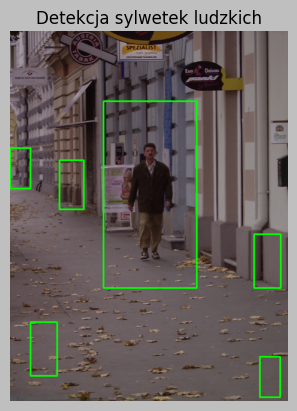

In [91]:
# image = cv2.imread("train/pos/per00004.ppm")
image = cv2.imread("test/testImage2.png")

descriptor = classifier.compute_descriptor(image)
print(classifier.clf.predict(descriptor.reshape(1, -1)))

detector = HumanDetector(classifier, step_size=8, window_size=(32, 64), scale_factor=1.1)
detections, image_with_boxes = detector.detect_multiscale(image, visualize=True, multiscale=True)

plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.title("Detekcja sylwetek ludzkich")
plt.axis('off')
plt.show()